In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.integrate import cumulative_trapezoid
import sympy as sp

""" ----------------------------- Rayleigh Problem ----------------------- """

# Symobolic Solution
t, tau, t0 = sp.symbols('t tau t0', positive=True)
U, y0, nu = sp.symbols('U y0 nu', positive=True)

u_tau = U * sp.erfc(y0/sp.sqrt(4*nu*tau))
x_t = sp.integrate(u_tau, (tau, t0, t))

sp.simplify(x_t)
display(x_t)

U*(-t*erf(y0/(2*sqrt(nu)*sqrt(t))) + t - y0**2*erf(y0/(2*sqrt(nu)*sqrt(t)))/(2*nu) - sqrt(t)*y0*exp(-y0**2/(4*nu*t))/(sqrt(pi)*sqrt(nu))) - U*(-t0*erf(y0/(2*sqrt(nu)*sqrt(t0))) + t0 - y0**2*erf(y0/(2*sqrt(nu)*sqrt(t0)))/(2*nu) - sqrt(t0)*y0*exp(-y0**2/(4*nu*t0))/(sqrt(pi)*sqrt(nu)))

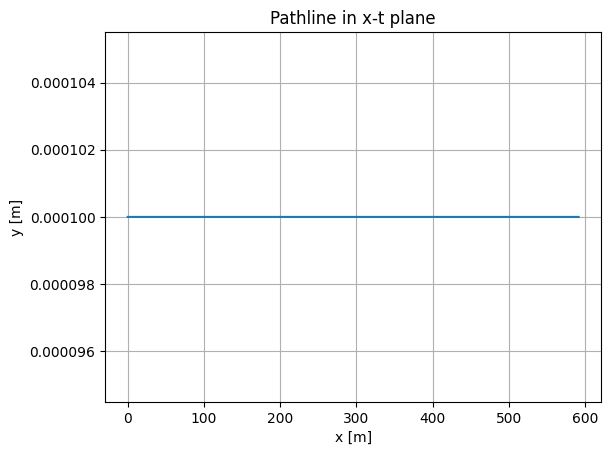

In [8]:
# Graphical Solution

U = 10      # Flow velocity
nu = 1e-6   # Dynamic Viscosity
y0 = 1e-4   # m
t0 = 1e-3   # s
tf = 60     # s

def u_of_t(t):
    t = np.asarray(t)
    return U*erfc(y0/np.sqrt(4*nu*t))

N = 2000
t = np.linspace(t0, tf, N)
u = u_of_t(t)

x = cumulative_trapezoid(u, t, initial=0)

y = np.full_like(t, y0)

plt.figure()
plt.plot(x,y)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Pathline in x-t plane')
plt.grid(True)

plt.show()